# 🏝️ **A Survival Guide to the Island's Berries**

## **Part 1: Unsupervised Clustering of Berry Diversity**

### **Goal:** To make sense of the diversity of berries on the island by grouping them into natural clusters using the data from `clustering.json`.

### Methodology:
1.  **Explore the Data:** Load `clustering.json` and analyze the features.
2.  **Initial Clustering:** Apply K-Means and Gaussian Mixture Models (GMM) to the raw data to find initial clusters.
3.  **Experimentation:** Investigate how the clusters change when using different features or a different number of clusters (K).
4.  **Feature Engineering:** Create a new derived feature, `growth_rate`, to see if it helps in forming clearer, more meaningful clusters.


### **Import Libraries & Modules**

In [6]:
# Import necessary libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.mixture import GaussianMixture as SklearnGMM
from sklearn.metrics import silhouette_score

# Import Custom Modules
scripts_path = os.path.abspath(os.path.join('..', 'scripts'))
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

from kmeans import kmeans_custom
from gmm import exp_max_custom, normal_pdf, normal_train

print("All libraries and custom modules imported successfully.")

All libraries and custom modules imported successfully.


### **Load Data and Define Visual Style**

In [7]:
# Define a Unified Color Palette
PALETTE = {
    'background': '#f1faee', 'primary_text': '#264653',
    'accent': '#f4a261',
    'cluster_colors': ['#E15554', '#4D9DE0', '#3BB273', '#E1BC29', '#7768AE']
}

# Set the global plotting style
sns.set_style("whitegrid", {'axes.facecolor': PALETTE['background']})
plt.rc('figure', facecolor=PALETTE['background'])
plt.rc('axes', edgecolor=PALETTE['primary_text'], labelcolor=PALETTE['primary_text'], titlecolor=PALETTE['primary_text'])
plt.rc('text', color=PALETTE['primary_text'])
plt.rc('xtick', color=PALETTE['primary_text'])
plt.rc('ytick', color=PALETTE['primary_text'])

# Load the Dataset
base_path = os.path.join('..', 'data')
try:
    cluster_df = pd.read_json(os.path.join(base_path, 'clustering.json'))
    print("Clustering dataset loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading data: {e}.")

Clustering dataset loaded successfully.


### **Exploratory Data Analysis (EDA)**

1. First 5 rows of the dataset:
╒════╤═════════╤═════════════╤══════════════╤══════════════╤════════════════╤══════════╕
│    │     age │   leaf_size │   berry_size │   petal_size │   soil_quality │   height │
╞════╪═════════╪═════════════╪══════════════╪══════════════╪════════════════╪══════════╡
│  0 │ 1.08732 │     28.8127 │     10.0853  │      4.51706 │        5.34395 │  50.7253 │
├────┼─────────┼─────────────┼──────────────┼──────────────┼────────────────┼──────────┤
│  1 │ 8.41628 │     31.3251 │      6.69515 │      1.47916 │        4.37173 │ 290.381  │
├────┼─────────┼─────────────┼──────────────┼──────────────┼────────────────┼──────────┤
│  2 │ 9.77532 │     22.536  │      9.56228 │      3.98337 │        4.96016 │ 408.957  │
├────┼─────────┼─────────────┼──────────────┼──────────────┼────────────────┼──────────┤
│  3 │ 7.48901 │     16.599  │      3.5405  │      3.11734 │        3.15318 │ 228.011  │
├────┼─────────┼─────────────┼──────────────┼──────────────┼────────────────┼─

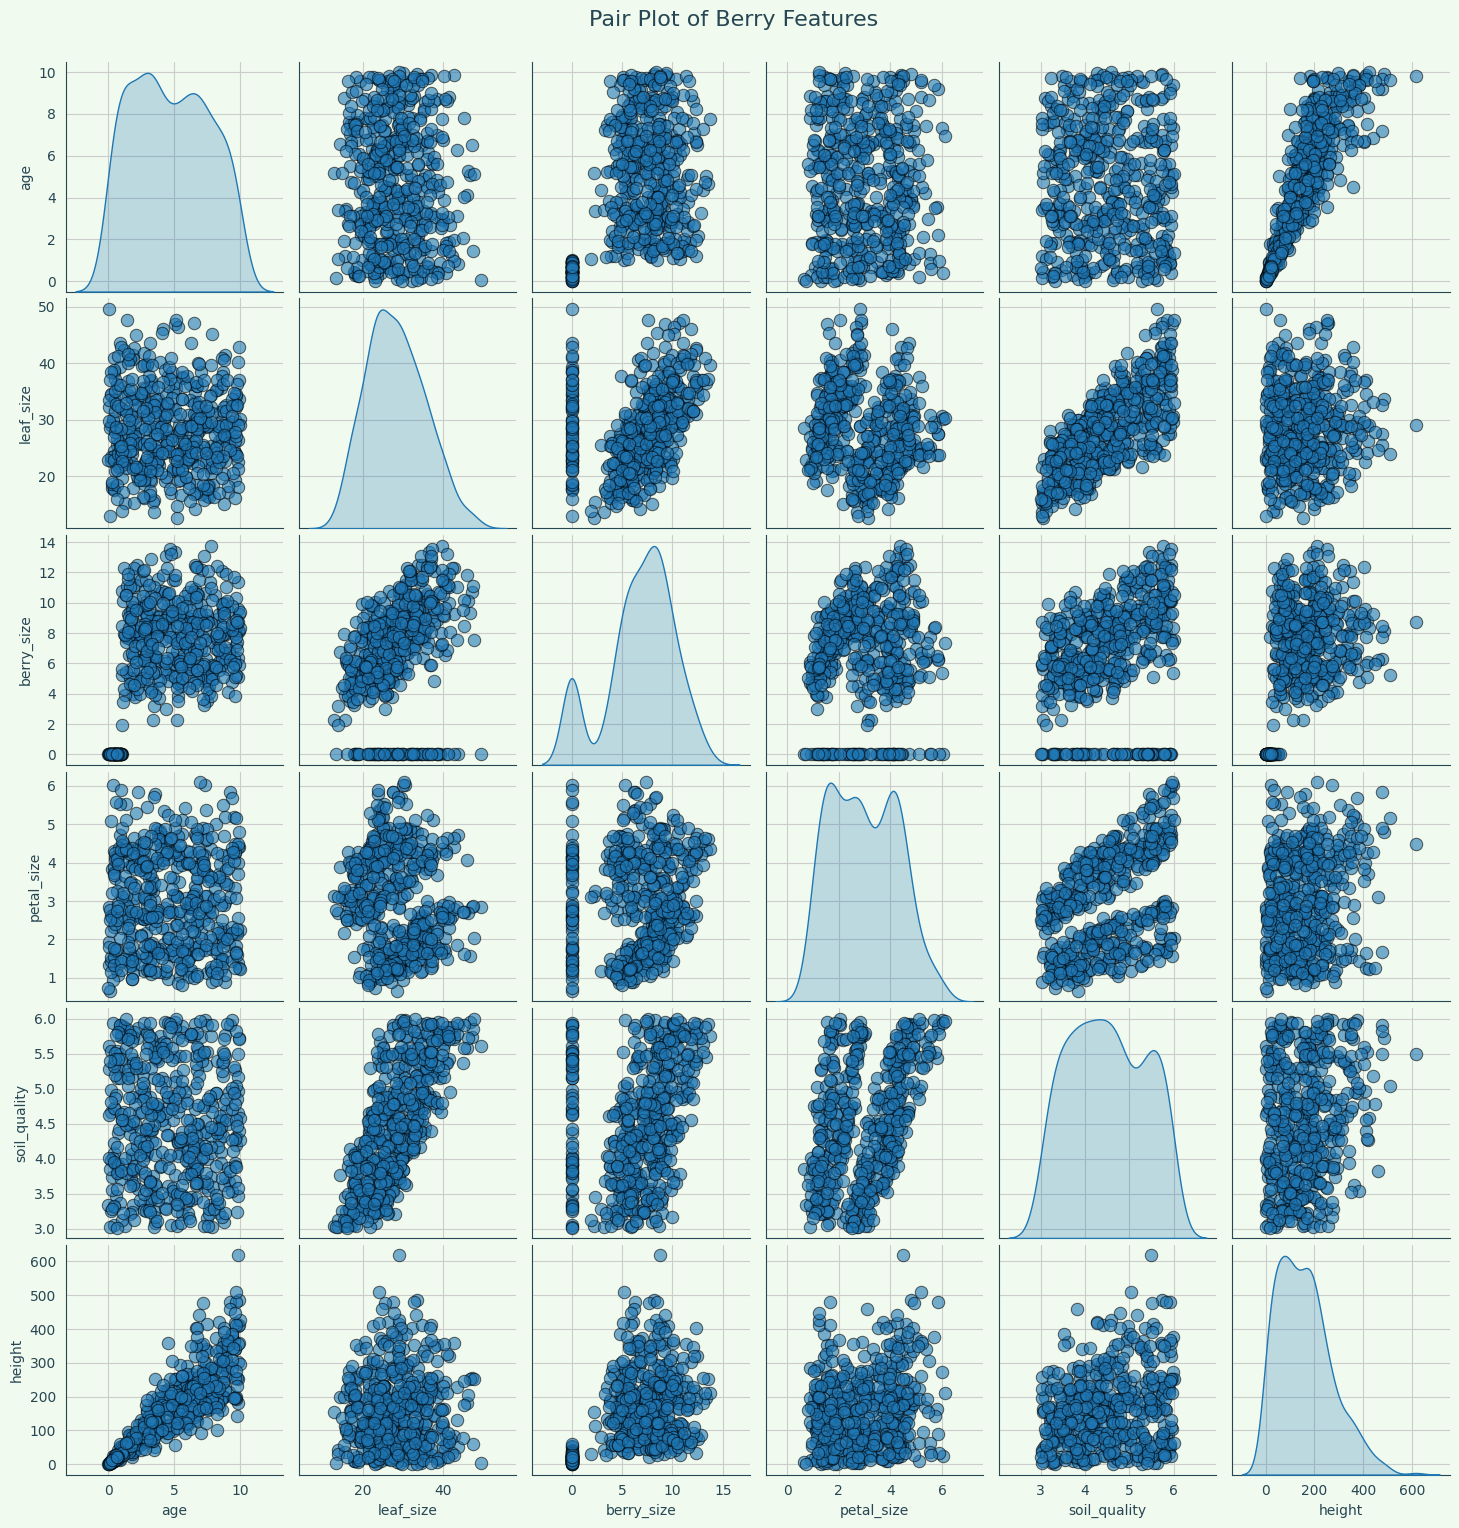

In [8]:
# Display Basic Information about the Dataset
# Display the first few rows of the dataset
print("1. First 5 rows of the dataset:")
print(tabulate(cluster_df.head(), headers='keys', tablefmt='fancy_grid'))

print("\n2. Basic DataFrame Information")
info_data = {
    "Shape": [f"{cluster_df.shape[0]} rows, {cluster_df.shape[1]} columns"],
    "Memory Usage": [f"{cluster_df.memory_usage(deep=True).sum() / 1024:.2f} KB"],
    "Missing Values": ["None" if cluster_df.isnull().sum().sum() == 0 else "Present"]
}
print(tabulate(info_data, headers="keys", tablefmt="fancy_grid"))

# Display dataset info and descriptive statistics
print("\n3. Data Types and Non-Null Counts")
info_df = pd.DataFrame({
    'Column': cluster_df.columns,
    'Non-Null Count': cluster_df.count().values,
    'Data Type': cluster_df.dtypes.values
})
print(tabulate(info_df, headers="keys", tablefmt="fancy_grid", showindex=False))

# Display descriptive statistics
print("\n 4. Descriptive Statistics")
print(tabulate(cluster_df.describe(), headers='keys', tablefmt='fancy_grid'))

# Visualize Feature Distributions
print("\n 5. Visualizing Feature Distributions")
sns.pairplot(cluster_df, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 80, 'edgecolor': 'k'})
plt.suptitle('Pair Plot of Berry Features', y=1.02, fontsize=16)
plt.show()


Observations:

1. **Height vs. Age**

   * There’s a strong positive linear relationship. As the plant’s **age increases**, its **height increases almost proportionally**. This suggests growth is steady over time.

2. **Leaf Size vs. Age / Height**

   * **Leaf size** also increases with both **age** and **height**, though with more variability. Taller (and older) plants tend to have larger leaves, but there’s a spread — meaning leaf size isn’t perfectly determined by age/height.

3. **Berry Size & Petal Size**

   * Both **berry size** and **petal size** show positive associations with **leaf size** and **height**. Larger plants seem to invest in bigger berries and petals, hinting at a resource-allocation pattern.

4. **Soil Quality**

   * Soil quality doesn’t vary continuously across the scatter plots; it looks **categorical (discrete bands)**. Plants are grouped into distinct soil-quality levels, and within each level, the relationships with other features remain consistent.

5. **Distributions**

   * **Age** is uniformly distributed.
   * **Height** is right-skewed (many short plants, fewer tall ones).
   * **Berry size** has a peak at small values but also a spread into larger values.
   * **Soil quality** shows multiple peaks (discrete bins, not continuous).

**Key takeaway**:
Berry plants grow **taller and develop larger leaves, berries, and petals as they age**. Soil quality acts more like a categorical condition — creating clusters, but not altering the overall growth pattern.

### **Initial Clustering (All Features)**


INITIAL CLUSTERING (ALL FEATURES, K=3)


/tmp/ipykernel_222702/2437800633.py:49: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=PALETTE['cluster_colors'], ax=ax, s=50, legend='full')
/tmp/ipykernel_222702/2437800633.py:49: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=PALETTE['cluster_colors'], ax=ax, s=50, legend='full')
/tmp/ipykernel_222702/2437800633.py:49: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=PALETTE['cluster_colors'], ax=ax, s=50, legend='full')
/tmp/ipykernel_222702/2437800633.py:49: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=PAL

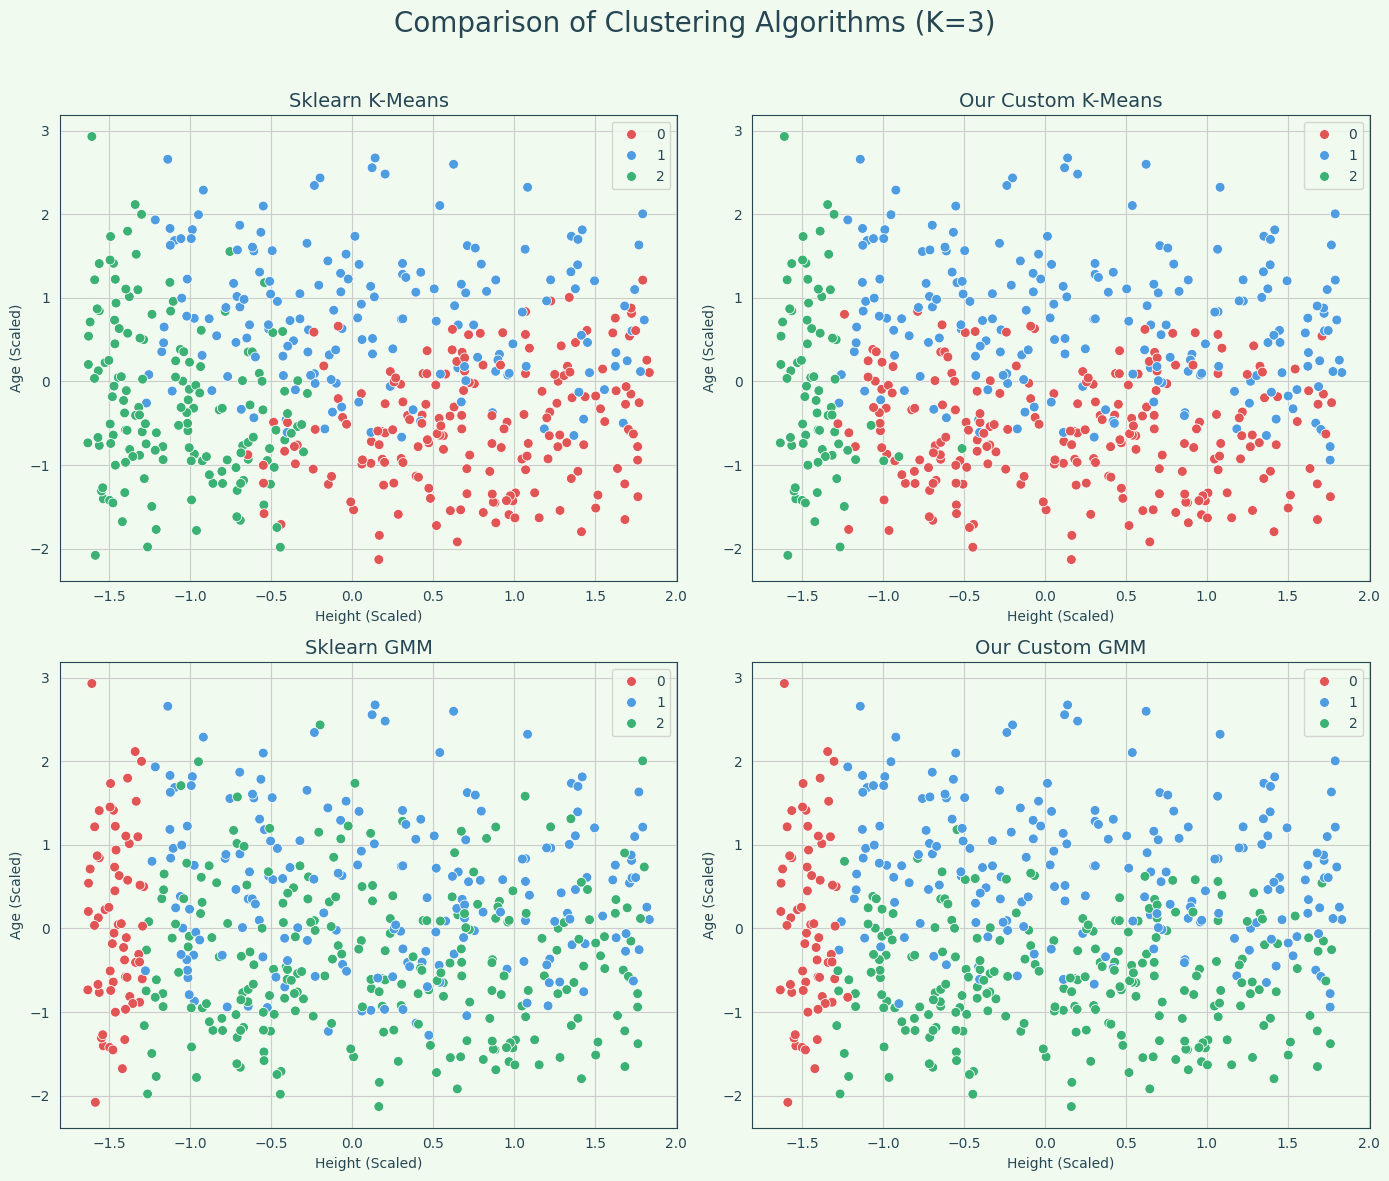

In [9]:
print("\n" + "="*80)
print("INITIAL CLUSTERING (ALL FEATURES, K=3)")
print("="*80)

# Prepare and Scale Data
# Scaling is crucial for distance-based algorithms like K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

# Initialize Parameters for Custom Algorithms
K = 3
n, D = X_scaled.shape
eps = 1e-5
# Initialize centroids for K-Means by picking K random points from the data
initial_centroids = X_scaled[np.random.choice(n, K, replace=False)].T
# Initialize parameters for GMM
initial_weights = np.ones((1, K)) / K
initial_means = X_scaled[np.random.choice(n, K, replace=False)].T

# Run Clustering Models
# Sklearn K-Means
sklearn_kmeans = SklearnKMeans(n_clusters=K, random_state=42, n_init=10)
labels_sklearn_kmeans = sklearn_kmeans.fit_predict(X_scaled)

# Custom K-Means
centroids_custom, labels_custom_kmeans = kmeans_custom(eps, K, X_scaled, initial_centroids)

# Sklearn GMM
sklearn_gmm = SklearnGMM(n_components=K, random_state=42)
labels_sklearn_gmm = sklearn_gmm.fit_predict(X_scaled)

# Custom GMM (EM)
# Note: Our custom GMM is simplified (fixed variance), so results may differ.
weights_custom, means_custom, labels_custom_gmm = exp_max_custom(
    100, K, normal_pdf, normal_train, X_scaled, initial_weights, initial_means, var=1.0
)

# Visualize Results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Comparison of Clustering Algorithms (K=3)', fontsize=20)
plot_data = [
    ("Sklearn K-Means", labels_sklearn_kmeans, axes[0, 0]),
    ("Our Custom K-Means", labels_custom_kmeans, axes[0, 1]),
    ("Sklearn GMM", labels_sklearn_gmm, axes[1, 0]),
    ("Our Custom GMM", labels_custom_gmm, axes[1, 1])
]

for title, labels, ax in plot_data:
    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=PALETTE['cluster_colors'], ax=ax, s=50, legend='full')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Height (Scaled)')
    ax.set_ylabel('Age (Scaled)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### **Observations**

1. **Cluster Shape & Boundaries**

   * **K-Means (both Sklearn & Custom)**: Clusters are divided more or less vertically, grouping based on *height* rather than *age*. Boundaries look sharp and linear, which matches how K-Means partitions data.
   * **GMM (both Sklearn & Custom)**: Clusters appear smoother and more overlapping. The assignments seem influenced by both *age* and *height*, which is expected since GMM assumes Gaussian distributions.

2. **Consistency Between Implementations**

   * Your **Custom K-Means** is fairly consistent with **Sklearn K-Means**, though the boundaries are shifted (Sklearn separated more by height, Custom leans toward age-height mixing).
   * Similarly, **Custom GMM** produces clusters resembling Sklearn’s GMM but with slight differences in how boundary overlap is handled. This suggests your implementation logic is working but may differ in initialization or convergence tolerance.

3. **Cluster Separation Quality**

   * Neither algorithm shows **perfect separation** — clusters overlap heavily. This suggests the features *Age* and *Height* alone may not provide strong discriminatory power for natural clusters.
   * GMM results look more realistic given the data’s spread, while K-Means enforces rigid partitions that might not capture the underlying structure well.

**Key Takeaway:**
**Age and height alone are insufficient for meaningful clusters**. To improve results, introduce more features, reduce dimensionality, and validate with cluster metrics.


### **Experimenting with Number of Clusters (K)**


FINDING THE OPTIMAL NUMBER OF CLUSTERS (K)


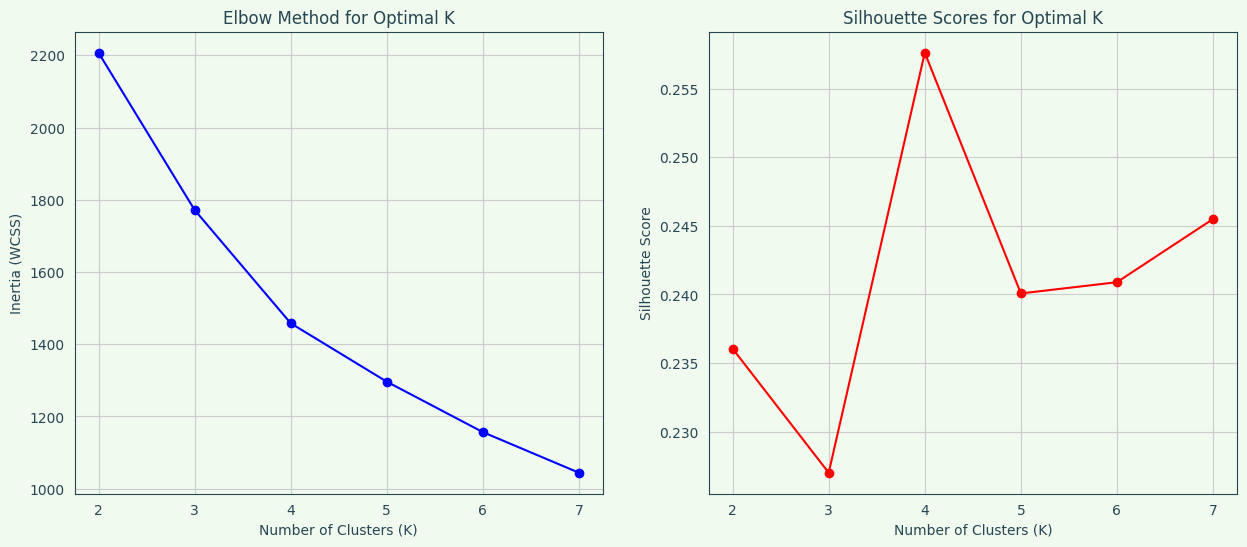

In [10]:
print("\n" + "="*80)
print("FINDING THE OPTIMAL NUMBER OF CLUSTERS (K)")
print("="*80)

# We use the "Elbow Method" and Silhouette Score to find the best K for Sklearn's K-Means
inertia_scores = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = SklearnKMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot the Elbow Method and Silhouette Scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(k_range, inertia_scores, 'bo-')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method for Optimal K')

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores for Optimal K')
plt.show()


### **Elbow Method (Left Plot)**

* The inertia (WCSS) decreases as K increases, but the rate of improvement slows down around **K=4**.
* This “elbow” at **K=4** suggests diminishing returns beyond that point.

### **Silhouette Scores (Right Plot)**

* The silhouette score peaks at **K=4** (≈ 0.258), which is higher than the other values.
* This indicates clusters are more compact and well-separated at **K=4**.

**Optimal K = 4**
Both methods (Elbow and Silhouette) agree that **K=4** is the best choice for clustering this dataset.



INITIAL CLUSTERING (ALL FEATURES, K=4)


/tmp/ipykernel_222702/2287872684.py:49: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=PALETTE['cluster_colors'], ax=ax, s=50, legend='full')
/tmp/ipykernel_222702/2287872684.py:49: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=PALETTE['cluster_colors'], ax=ax, s=50, legend='full')
/tmp/ipykernel_222702/2287872684.py:49: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=PALETTE['cluster_colors'], ax=ax, s=50, legend='full')
/tmp/ipykernel_222702/2287872684.py:49: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=PAL

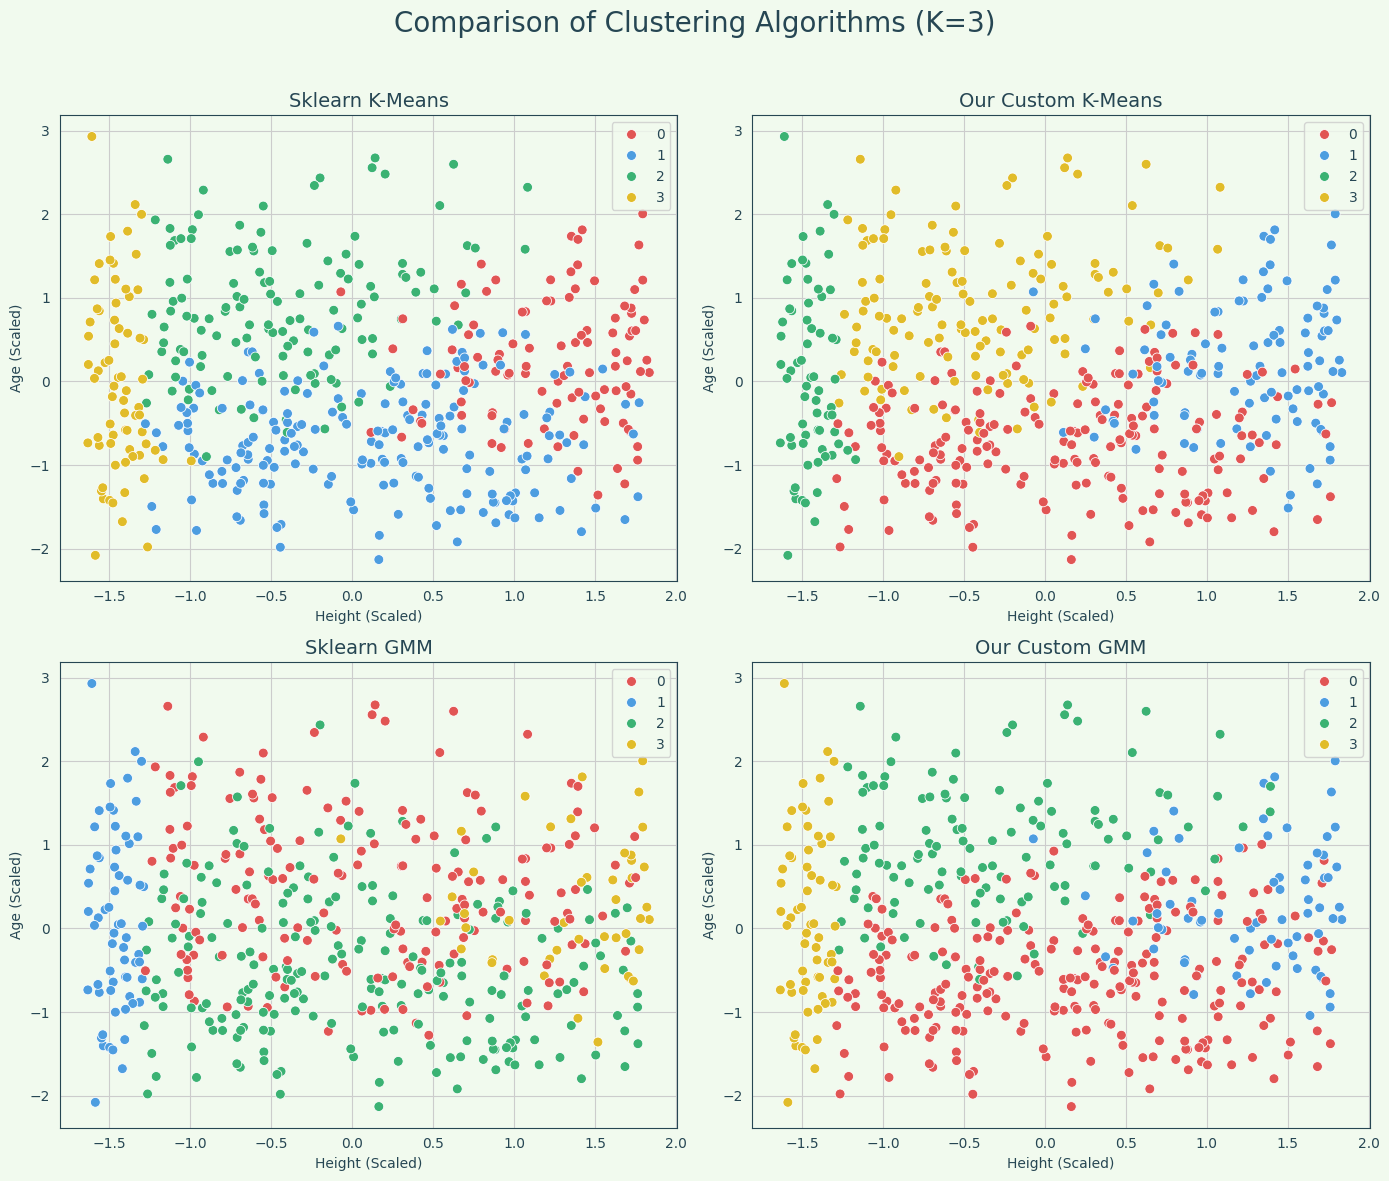

In [11]:
print("\n" + "="*80)
print("INITIAL CLUSTERING (ALL FEATURES, K=4)")
print("="*80)

# Prepare and Scale Data
# Scaling is crucial for distance-based algorithms like K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

# Initialize Parameters for Custom Algorithms
K = 4
n, D = X_scaled.shape
eps = 1e-5
# Initialize centroids for K-Means by picking K random points from the data
initial_centroids = X_scaled[np.random.choice(n, K, replace=False)].T
# Initialize parameters for GMM
initial_weights = np.ones((1, K)) / K
initial_means = X_scaled[np.random.choice(n, K, replace=False)].T

# Run Clustering Models
# Sklearn K-Means
sklearn_kmeans = SklearnKMeans(n_clusters=K, random_state=42, n_init=10)
labels_sklearn_kmeans = sklearn_kmeans.fit_predict(X_scaled)

# Custom K-Means
centroids_custom, labels_custom_kmeans = kmeans_custom(eps, K, X_scaled, initial_centroids)

# Sklearn GMM
sklearn_gmm = SklearnGMM(n_components=K, random_state=42)
labels_sklearn_gmm = sklearn_gmm.fit_predict(X_scaled)

# Custom GMM (EM)
# Note: Our custom GMM is simplified (fixed variance), so results may differ.
weights_custom, means_custom, labels_custom_gmm = exp_max_custom(
    100, K, normal_pdf, normal_train, X_scaled, initial_weights, initial_means, var=1.0
)

# Visualize Results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Comparison of Clustering Algorithms (K=3)', fontsize=20)
plot_data = [
    ("Sklearn K-Means", labels_sklearn_kmeans, axes[0, 0]),
    ("Our Custom K-Means", labels_custom_kmeans, axes[0, 1]),
    ("Sklearn GMM", labels_sklearn_gmm, axes[1, 0]),
    ("Our Custom GMM", labels_custom_gmm, axes[1, 1])
]

for title, labels, ax in plot_data:
    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels, palette=PALETTE['cluster_colors'], ax=ax, s=50, legend='full')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Height (Scaled)')
    ax.set_ylabel('Age (Scaled)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### **Recursive Clustering with Different Feature Combinations**

In [12]:
print("\n" + "="*80)
print("RECURSIVE CLUSTERING WITH DIFFERENT FEATURE COMBINATIONS")
print("="*80)

# 1. Define the Helper Function
# This function will perform the clustering and evaluation for a given set of features.
def evaluate_clustering(df, features, k=3):
    """
    Performs K-Means clustering on a dataframe with a specific subset of features
    and returns the silhouette score.
    
    Args:
        df (pd.DataFrame): The source dataframe.
        features (list): A list of feature names to use for clustering.
        k (int): The number of clusters.
        
    Returns:
        float: The silhouette score for the resulting clusters. Returns -1 if clustering fails.
    """
    if not features:
        return -1 # Cannot cluster on zero features

    # Prepare and scale the data for the selected features
    X = df[features].values
    
    # Scaling is crucial, especially when combining features of different units
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Cannot compute silhouette score with only one sample
    if X_scaled.shape[0] < 2:
        return -1

    # Perform K-Means clustering
    kmeans = SklearnKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Calculate and return the silhouette score
    # Requires at least 2 labels to be present.
    if len(set(labels)) < 2:
        return -1
        
    score = silhouette_score(X_scaled, labels)
    return score

# 2. Define the Recursive Function
# This function will generate all feature combinations and call the helper function.
def find_best_feature_combo(df, features_to_try, current_combo=[], all_results=None):
    """
    Recursively finds the best feature combination for clustering based on silhouette score.
    
    Args:
        df (pd.DataFrame): The source dataframe.
        features_to_try (list): The list of features remaining to be added.
        current_combo (list): The current combination of features being tested.
        all_results (list): A list to store results from all recursive calls.
    """
    if all_results is None:
        all_results = []

    # --- Base Case ---
    # If there are no more features to add, we stop this path of recursion.
    if not features_to_try:
        return all_results

    # --- Recursive Step ---
    # Iterate through the remaining features to add to our current combination.
    for i, feature_to_add in enumerate(features_to_try):
        
        # Create the new combination
        new_combo = current_combo + [feature_to_add]
        
        # Evaluate the new combination
        score = evaluate_clustering(df, new_combo, k=3)
        
        # Store the result
        result = {
            "Features": ", ".join(new_combo),
            "Num_Features": len(new_combo),
            "Silhouette_Score": score
        }
        all_results.append(result)
        
        print(f"Tested Combo: {new_combo} | Score: {score:.4f}")
        
        # The recursive call: try adding the *next* features to this new combo
        # We pass features_to_try[i+1:] to avoid duplicate combinations (e.g., [A,B] and [B,A])
        find_best_feature_combo(df, features_to_try[i+1:], new_combo, all_results)
        
    return all_results

# 3. Run the Recursive Analysis
# Get the list of all features from the dataframe
all_features = cluster_df.columns.tolist()
print(f"Starting recursive analysis on features: {all_features}\n")

# Run the function and get the results
clustering_results = find_best_feature_combo(cluster_df, all_features)

# 4. Process and Display the Final Results
# Convert results to a DataFrame for easy sorting and display
results_df = pd.DataFrame(clustering_results)
results_df.sort_values(by="Silhouette_Score", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

print("\n Clustering Performance by Feature Combination (Sorted by Best Score)")
print(tabulate(results_df, headers="keys", tablefmt="fancy_grid"))




RECURSIVE CLUSTERING WITH DIFFERENT FEATURE COMBINATIONS
Starting recursive analysis on features: ['age', 'leaf_size', 'berry_size', 'petal_size', 'soil_quality', 'height']

Tested Combo: ['age'] | Score: 0.5645
Tested Combo: ['age', 'leaf_size'] | Score: 0.3877
Tested Combo: ['age', 'leaf_size', 'berry_size'] | Score: 0.3420
Tested Combo: ['age', 'leaf_size', 'berry_size', 'petal_size'] | Score: 0.2636
Tested Combo: ['age', 'leaf_size', 'berry_size', 'petal_size', 'soil_quality'] | Score: 0.2723
Tested Combo: ['age', 'leaf_size', 'berry_size', 'petal_size', 'soil_quality', 'height'] | Score: 0.2270
Tested Combo: ['age', 'leaf_size', 'berry_size', 'petal_size', 'height'] | Score: 0.2314
Tested Combo: ['age', 'leaf_size', 'berry_size', 'soil_quality'] | Score: 0.3372
Tested Combo: ['age', 'leaf_size', 'berry_size', 'soil_quality', 'height'] | Score: 0.2858
Tested Combo: ['age', 'leaf_size', 'berry_size', 'height'] | Score: 0.3040
Tested Combo: ['age', 'leaf_size', 'petal_size'] | Score

### **Key Observations**

1. **Single features dominate**

   * The highest silhouette scores come from using **just one feature**:

     * `berry_size` (0.617)
     * `soil_quality` (0.603)
     * `petal_size` (0.594)
     * `height` (0.592)
     * These are **very strong scores** compared to multi-feature combinations.

2. **Adding more features reduces cluster quality**

   * As soon as you add 2+ features, scores typically **drop** into the 0.3–0.4 range.
   * The full feature set (`age, leaf_size, berry_size, petal_size, soil_quality, height`) performs **worst** with **0.227**.
   * This suggests **noise and redundancy** dilute cluster structure.

3. **Best 2-feature combos**

   * `age, height` (0.505)
   * `age, berry_size` (0.466)
   * `leaf_size, berry_size` (0.462)
   * These are significantly weaker than the best single features.

4. **Best 3+ feature combos**

   * `age, berry_size, height` (0.434)
   * `leaf_size, berry_size, soil_quality` (0.418)
   * `berry_size, soil_quality, height` (0.362)
   * Still weaker than the **best singles**.

### **Interpretation**

* Best single feature = **berry\_size**
* Best pair = **age + height**
* Adding everything **hurts performance** so we focus on **selective features or dimensionality reduction**.


### **Clustering with Prioritized Features (K=4)**


CLUSTERING ANALYSIS WITH PRIORITIZED FEATURES (K=4)
Features: age, leaf_size, berry_size, petal_size, soil_quality, height


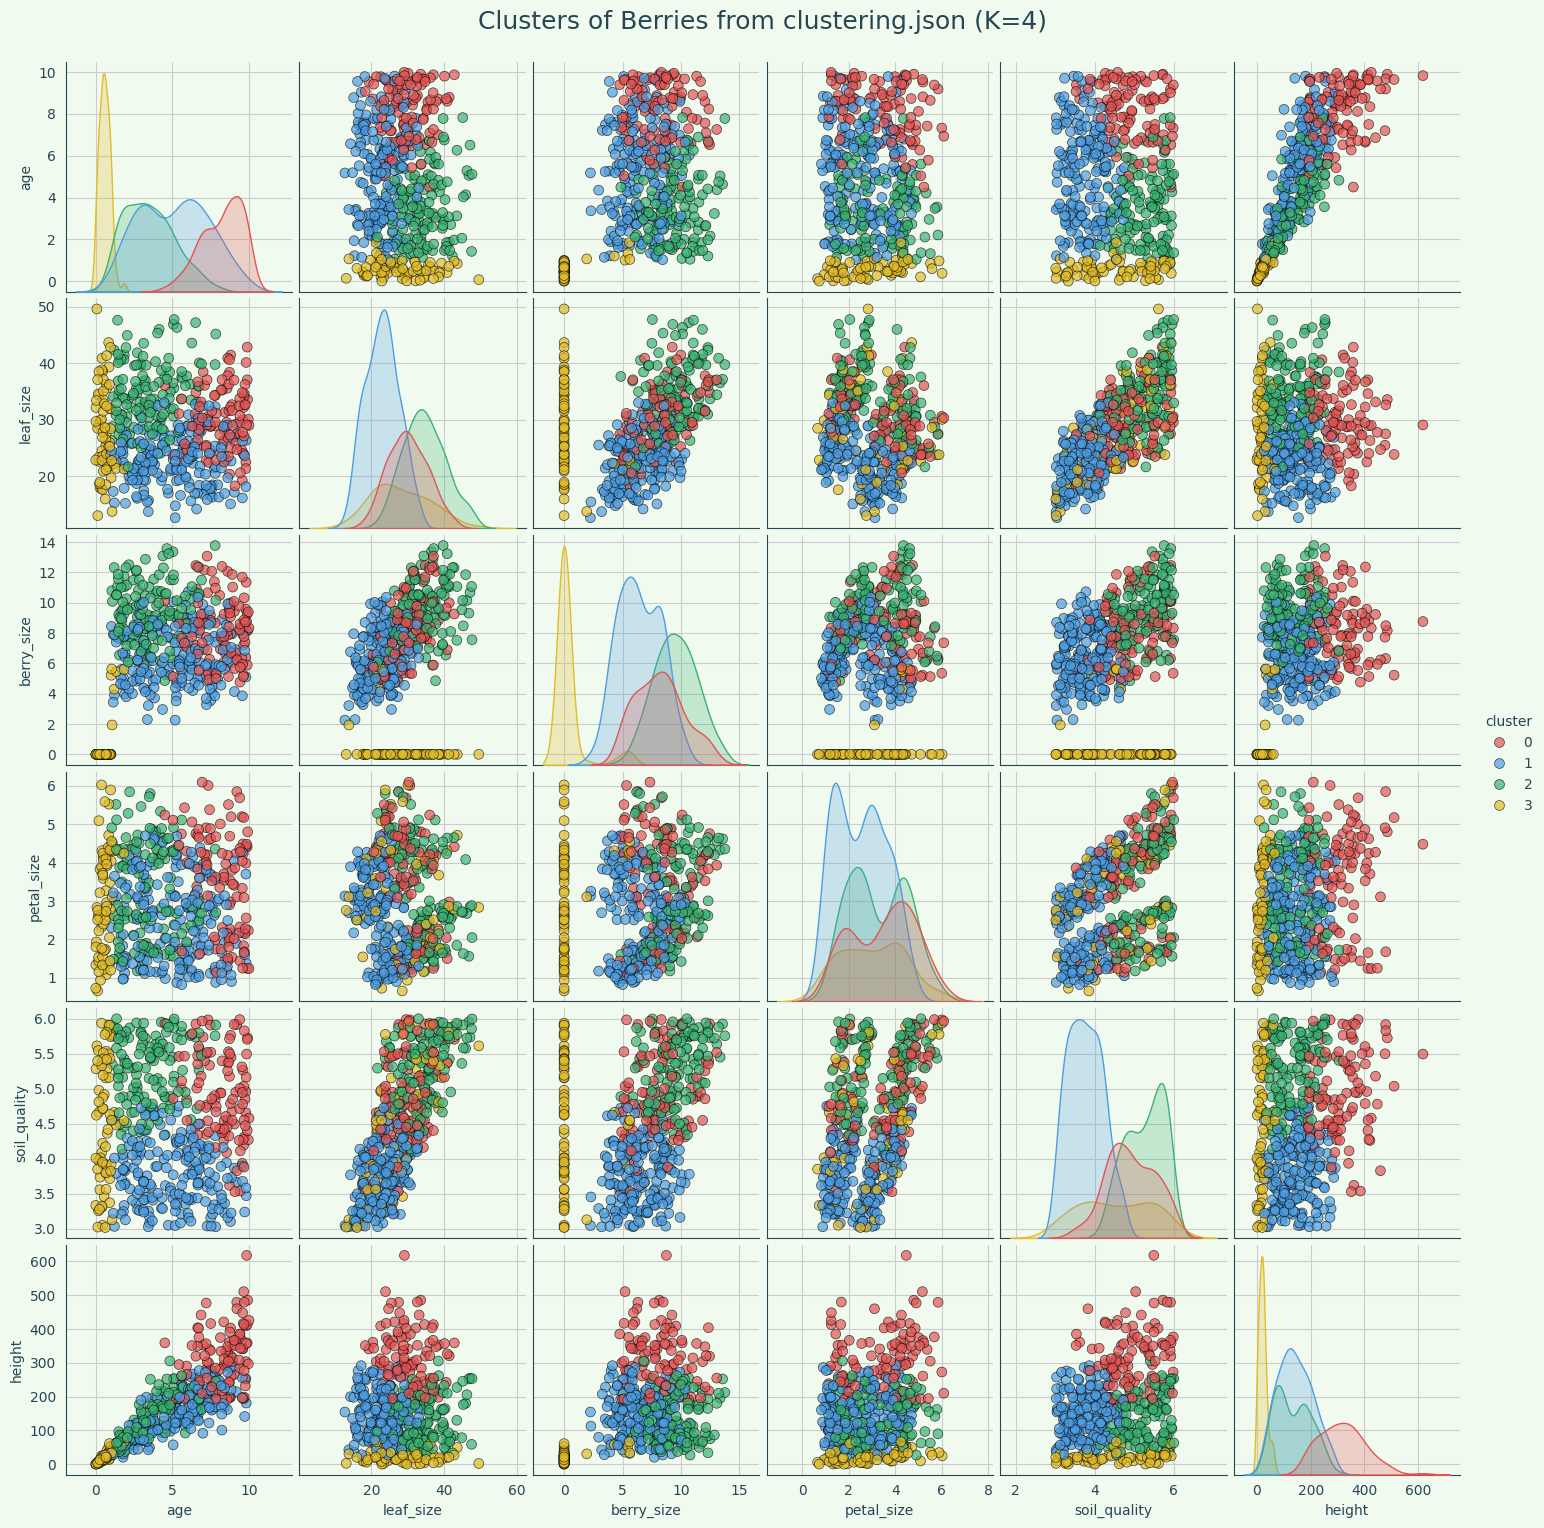


 4.1. Average Characteristics of Each Cluster
╒═══════════╤══════════╤═════════════╤══════════════╤══════════════╤════════════════╤══════════╕
│   cluster │      age │   leaf_size │   berry_size │   petal_size │   soil_quality │   height │
╞═══════════╪══════════╪═════════════╪══════════════╪══════════════╪════════════════╪══════════╡
│         0 │ 8.20265  │     29.9994 │     8.20536  │      3.48205 │        4.91422 │ 317.861  │
├───────────┼──────────┼─────────────┼──────────────┼──────────────┼────────────────┼──────────┤
│         1 │ 5.11273  │     22.9425 │     6.44347  │      2.52946 │        3.76663 │ 143.211  │
├───────────┼──────────┼─────────────┼──────────────┼──────────────┼────────────────┼──────────┤
│         2 │ 3.50669  │     34.6409 │     9.53941  │      3.27188 │        5.26698 │ 134.346  │
├───────────┼──────────┼─────────────┼──────────────┼──────────────┼────────────────┼──────────┤
│         3 │ 0.577295 │     28.1469 │     0.407549 │      3.03342 │        4.52

In [16]:
print("\n" + "="*80)
print("CLUSTERING ANALYSIS WITH PRIORITIZED FEATURES (K=4)")
print("="*80)

# 1. Select and Prepare the Data
features_to_use = ['age', 'leaf_size', 'berry_size', 'petal_size', 'soil_quality', 'height']
df_for_clustering = cluster_df[features_to_use].copy()

print(f"Features: {', '.join(features_to_use)}")

# Scaling is essential for K-Means to work correctly, as it prevents features
# with larger scales (like height) from dominating the distance calculations.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_for_clustering)

# 2. Perform K-Means Clustering
K = 4
kmeans = SklearnKMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the cluster labels back to our dataframe for visualization
df_for_clustering['cluster'] = cluster_labels

# 3. Visualize the Clusters
# Define a color palette for the 4 clusters
cluster_palette = {0: '#E15554', 1: '#4D9DE0', 2: '#3BB273', 3: '#E1BC29'}

pairplot_grid = sns.pairplot(
    df_for_clustering,
    hue='cluster',          # Color points by their assigned cluster
    palette=cluster_palette,
    diag_kind='kde',        # Show density plots on the diagonal
    plot_kws={'alpha': 0.7, 's': 50, 'edgecolor': 'k', 'linewidth': 0.5}
)

pairplot_grid.fig.suptitle(f'Clusters of Berries from clustering.json (K={K})', y=1.02, fontsize=18)
plt.show()

# 4. Analyze Cluster Characteristics
# Calculate the mean of each feature for each cluster to understand their nature.
cluster_centers = df_for_clustering.groupby('cluster').mean()

print("\n 4.1. Average Characteristics of Each Cluster")
print(tabulate(cluster_centers, headers='keys', tablefmt='fancy_grid'))


### **Clustering Results**

From the **pairplot graph** and the **average feature table**, we can see distinct patterns in how the berry bushes group together:

- **Cluster 0 (blue – mature bushes)**  
  - **From the table:** Oldest bushes (~8 years), tallest (~318 cm), good soil (4.9), medium leaves and berries.  
  - **From the graph:** These points spread widely in height vs. age, showing steady growth with age.  
  - 👉 Represents **mature, productive bushes** that are reliable sources of food.  

- **Cluster 1 (red – weaker mid-growth)**  
  - **From the table:** Mid-aged (~5 years), shorter (~143 cm), smaller berries, poorer soil (3.8).  
  - **From the graph:** Often overlaps with Cluster 0, but consistently shorter for the same age → shows weaker growth.  
  - 👉 These are **weaker, mid-growth plants**, producing less food.  

- **Cluster 2 (green – thriving young)**  
  - **From the table:** Young (~3.5 years), very large leaves (34.6), fairly big berries (9.5), best soil quality (5.3), but shorter (~134 cm).  
  - **From the graph:** Strong separation by leaf size and soil quality. Large leaves and berries stand out despite short height.  
  - 👉 These are **young, thriving bushes** with strong potential — a good sign for future survival.  

- **Cluster 3 (yellow – seedlings)**  
  - **From the table:** Very young (~0.6 years), almost no berries (0.4), tiny height (~21 cm). Soil is fine, but too early.  
  - **From the graph:** Clustered tightly at low age/height values with minimal berry size.  
  - 👉 These are **seedlings** — not useful for immediate food.  

---

### Overall Picture
- Clusters capture a **lifecycle progression**: seedlings (Cluster 3) → thriving young (Cluster 2) → mid-growth but weaker (Cluster 1) → mature and productive (Cluster 0).  
- **Soil quality and leaf size** are strong indicators of plant health (Cluster 2 stands out here).  
- **Berry size and height** grow with age, but not uniformly — Cluster 1 shows that even older plants can underperform in poor soil.  

**Survival takeaway:**  
Focus on **Cluster 0 (mature bushes)** for immediate food, and monitor **Cluster 2 (young thriving plants)** for long-term survival.  
Avoid relying on **Cluster 3 (seedlings)**, and treat **Cluster 1 (weaker bushes)** as low-priority backup.  


### **Clustering with Derived Feature (Growth Rate)**


CLUSTERING WITH A DERIVED FEATURE

 Data with Derived 'growth_rate' Feature (Sample)
╒════╤═════════╤═════════════╤══════════════╤══════════════╤════════════════╤══════════╤═══════════════╕
│    │     age │   leaf_size │   berry_size │   petal_size │   soil_quality │   height │   growth_rate │
╞════╪═════════╪═════════════╪══════════════╪══════════════╪════════════════╪══════════╪═══════════════╡
│  0 │ 1.08732 │     28.8127 │     10.0853  │      4.51706 │        5.34395 │  50.7253 │       46.6515 │
├────┼─────────┼─────────────┼──────────────┼──────────────┼────────────────┼──────────┼───────────────┤
│  1 │ 8.41628 │     31.3251 │      6.69515 │      1.47916 │        4.37173 │ 290.381  │       34.5023 │
├────┼─────────┼─────────────┼──────────────┼──────────────┼────────────────┼──────────┼───────────────┤
│  2 │ 9.77532 │     22.536  │      9.56228 │      3.98337 │        4.96016 │ 408.957  │       41.8356 │
├────┼─────────┼─────────────┼──────────────┼──────────────┼──────────────

/tmp/ipykernel_222702/3675811592.py:26: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(x=X_derived_scaled[:, 0], y=X_derived_scaled[:, 1], hue=labels_derived, palette=PALETTE['cluster_colors'], s=60, legend='full')


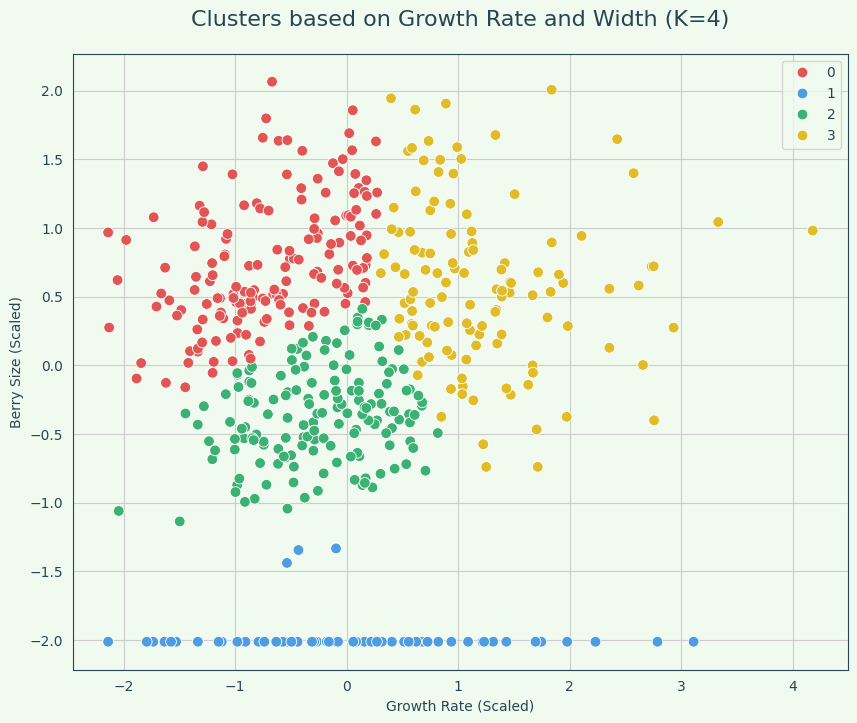

In [14]:
print("\n" + "="*80)
print("CLUSTERING WITH A DERIVED FEATURE")
print("="*80)

# Create the new feature
df_derived = cluster_df.copy()
# Add a small constant to age to avoid division by zero
df_derived['growth_rate'] = df_derived['height'] / (df_derived['age'] + 1e-6)

print("\n Data with Derived 'growth_rate' Feature (Sample)")
print(tabulate(df_derived.head(), headers='keys', tablefmt='fancy_grid'))

# Prepare and Scale the new dataset
# We will use 'growth_rate' and 'berry_size' for visualization
features_for_clustering = ['growth_rate', 'berry_size']
X_derived = df_derived[features_for_clustering].values
scaler_derived = StandardScaler()
X_derived_scaled = scaler_derived.fit_transform(X_derived)

# Cluster with the optimal K=4
kmeans_derived = SklearnKMeans(n_clusters=4, random_state=42, n_init=10)
labels_derived = kmeans_derived.fit_predict(X_derived_scaled)

# Visualize the new clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_derived_scaled[:, 0], y=X_derived_scaled[:, 1], hue=labels_derived, palette=PALETTE['cluster_colors'], s=60, legend='full')
plt.title('Clusters based on Growth Rate and Width (K=4)', fontsize=16, pad=20)
plt.xlabel('Growth Rate (Scaled)')
plt.ylabel('Berry Size (Scaled)')
plt.show()

### **Clustering with Derived Growth Rate Feature**

By adding **growth_rate = height ÷ age**, we can see which bushes are not only tall but also efficient growers.

**From the table:**  
- Growth rates vary widely (20 → 47 cm/year in the sample).  
- This makes it possible to spot bushes that are strong performers for their age.

**From the scatterplot:**  
- **Cluster 0 (red):** Steady growers with medium-to-large berries → decent short-term food.  
- **Cluster 1 (blue):** Very small berries regardless of growth → not useful for survival.  
- **Cluster 2 (green):** Weak growers with below-average berry size → unreliable.  
- **Cluster 3 (yellow):** Fast-growing bushes with good berry size → best long-term option.

**Survival takeaway:**  
- For **immediate food**, rely on **Cluster 0**.  
- For **future security**, keep an eye on **Cluster 3**.  
- **Avoid** Clusters 1 and 2, as they either don’t produce enough berries or grow poorly.